In [6]:
# Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import seaborn as sns
import matplotlib.pyplot as plt


In [7]:

# Load Dataset
df = pd.read_csv("Insurance claims data.csv")

# Display first rows
print(df.head())

# Basic Data Exploration
print("Dataset Shape:", df.shape)
print(df.info())

# Drop ID Column
df = df.drop("policy_id", axis=1)


# Handle Missing Values
df = df.dropna()


# Feature & Target Split
X = df.drop("claim_status", axis=1)
y = df["claim_status"]


# Encode Categorical Variables
label_encoder = LabelEncoder()

for col in X.select_dtypes(include='object').columns:
    X[col] = label_encoder.fit_transform(X[col])



   policy_id  subscription_length  vehicle_age  customer_age region_code  \
0  POL045360                  9.3          1.2            41          C8   
1  POL016745                  8.2          1.8            35          C2   
2  POL007194                  9.5          0.2            44          C8   
3  POL018146                  5.2          0.4            44         C10   
4  POL049011                 10.1          1.0            56         C13   

   region_density segment model fuel_type     max_torque  ... is_brake_assist  \
0            8794      C2    M4    Diesel  250Nm@2750rpm  ...             Yes   
1           27003      C1    M9    Diesel  200Nm@1750rpm  ...              No   
2            8794      C2    M4    Diesel  250Nm@2750rpm  ...             Yes   
3           73430       A    M1       CNG   60Nm@3500rpm  ...              No   
4            5410      B2    M5    Diesel  200Nm@3000rpm  ...              No   

  is_power_door_locks  is_central_locking is_power_steer

In [8]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


# Model 1: Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)


# Model 2: Decision Tree
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)



# Model 3: Random Forest
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 Logistic Regression Performance
Accuracy: 0.9363426913559177
Precision: 0.0
Recall: 0.0


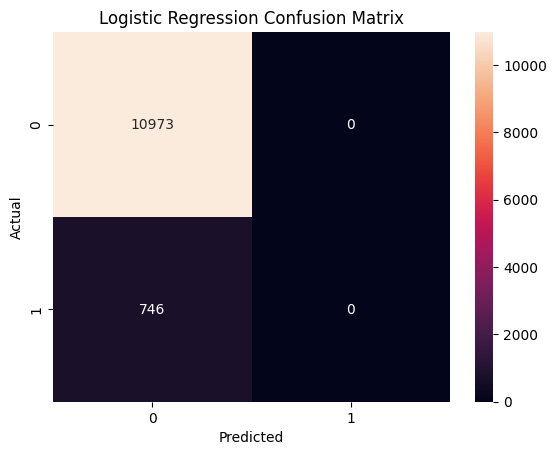


 Decision Tree Performance
Accuracy: 0.8723440566601246
Precision: 0.0795964125560538
Recall: 0.09517426273458444


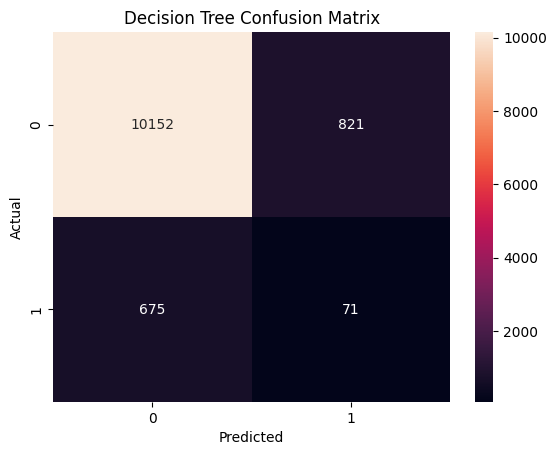


 Random Forest Performance
Accuracy: 0.9293455072958443
Precision: 0.06382978723404255
Recall: 0.00804289544235925


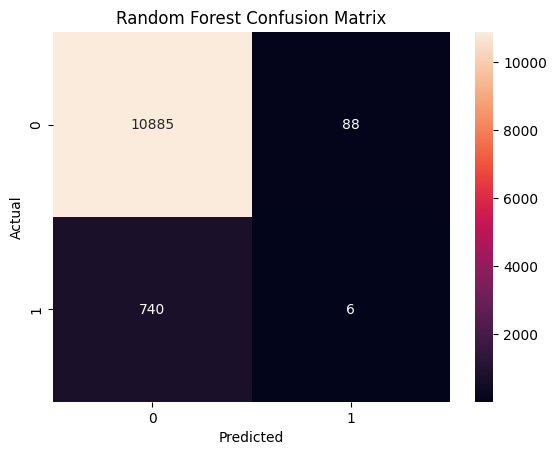

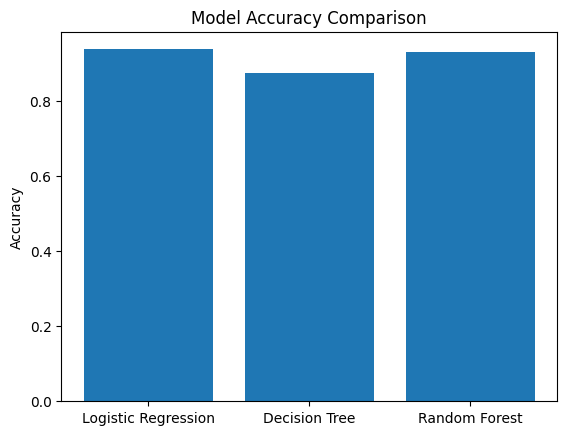

In [9]:

# Model Evaluation Function
def evaluate_model(y_test, predictions, model_name):

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)

    print("\n", model_name, "Performance")
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)

    cm = confusion_matrix(y_test, predictions)

    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(model_name + " Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


# Evaluate Models
evaluate_model(y_test, log_pred, "Logistic Regression")
evaluate_model(y_test, dt_pred, "Decision Tree")
evaluate_model(y_test, rf_pred, "Random Forest")


# Model Accuracy Comparison
accuracy_results = {
    "Logistic Regression": accuracy_score(y_test, log_pred),
    "Decision Tree": accuracy_score(y_test, dt_pred),
    "Random Forest": accuracy_score(y_test, rf_pred)
}

models = list(accuracy_results.keys())
scores = list(accuracy_results.values())

plt.bar(models, scores)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()